## import라이브러리

In [1]:
!pip install peft transformers accelerate bitsandbytes datasets wandb trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.9/310.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible

## 구글마운트

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from peft import LoraConfig, get_peft_model
import re
import wandb
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random
from nltk.corpus import wordnet
from nltk.tokenize import RegexpTokenizer
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
#nltk 추가 리소스 다운로드
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

#불용어 리스트 정의
stopword_list = nltk.corpus.stopwords.words('english')
stopword_list.remove('no')
stopword_list.remove('not')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/25603 [00:00<?, ? examples/s]

Map:   0%|          | 0/6401 [00:00<?, ? examples/s]

eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
train/epoch,▁▁
train/global_step,▁▁
train/grad_norm,▁
train/learning_rate,▁
train/loss,▁
eval/loss,0.64591
eval/runtime,2.423


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.651100
400,0.633400
600,0.610600
800,0.604600
1000,0.596000
1200,0.576100
1400,0.574600
1600,0.566000
1800,0.511400
2000,0.500200


훈련 완료, 모델 저장 완료
Accuracy after augmentation and hyperparameter tuning: 72.10%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.71      0.75      0.73      3201
        Real       0.74      0.69      0.71      3200

    accuracy                           0.72      6401
   macro avg       0.72      0.72      0.72      6401
weighted avg       0.72      0.72      0.72      6401



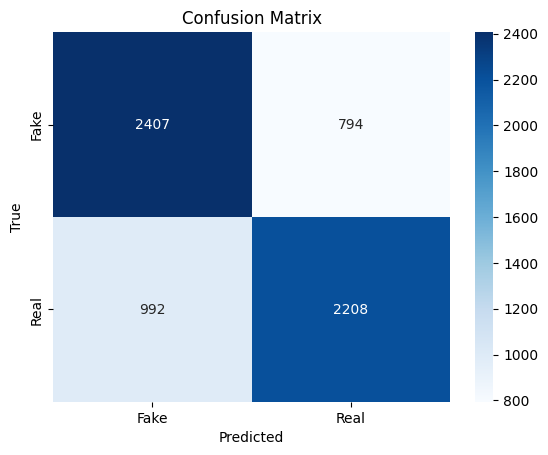

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['Review'] = augmented_reviews['Review'].apply(lambda x: synonym_replacement(x, n=2))

#기존 데이터셋과 증강된 데이터셋 결합
augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    augmented_df,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)


model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=312)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

wandb.init(project="distilbert-fake-real-review", name="distilbert-lora-training")

# TrainingArguments 설정 (하이퍼파라미터 튜닝 포함)
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2000,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 정의
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelp_output')
model.save_pretrained('/content/drive/MyDrive/results/yelp_output')

#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelp_output')
print("훈련 완료, 모델 저장 완료")

# 모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## 하이퍼파라미터

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/25603 [00:00<?, ? examples/s]

Map:   0%|          | 0/6401 [00:00<?, ? examples/s]

train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇██
train/grad_norm,▁▂▃▇▁▁▄▆█▃
train/learning_rate,█▇▆▆▅▄▃▃▂▁
train/loss,█▇▆▆▅▅▄▄▂▁
total_flos,2582064883618272.0
train/epoch,1.24922
train/global_step,2000
train/grad_norm,3.90903
train/learning_rate,0.0
train/loss,0.5002


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.649700
400,0.633900
600,0.611200
800,0.603800
1000,0.594200
1200,0.579000
1400,0.577000
1600,0.566000
1800,0.509600
2000,0.500500


훈련 완료, 모델 저장 완료
Accuracy after augmentation and hyperparameter tuning: 72.29%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.71      0.76      0.73      3201
        Real       0.74      0.69      0.71      3200

    accuracy                           0.72      6401
   macro avg       0.72      0.72      0.72      6401
weighted avg       0.72      0.72      0.72      6401



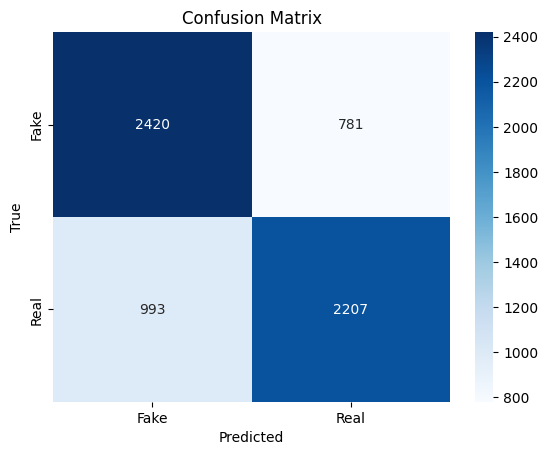

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['Review'] = augmented_reviews['Review'].apply(lambda x: synonym_replacement(x, n=2))

#기존 데이터셋과 증강된 데이터셋 결합
augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    augmented_df,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)


model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

wandb.init(project="distilbert-fake-real-review", name="distilbert-lora-training")

# TrainingArguments 설정 (하이퍼파라미터 튜닝 포함)
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2000,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 정의
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelp_output')
model.save_pretrained('/content/drive/MyDrive/results/yelp_output')

#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelp_output')
print("훈련 완료, 모델 저장 완료")

# 모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### 여러 개 중에서 이 부분 코드를 사용해주세요!model

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/25603 [00:00<?, ? examples/s]

Map:   0%|          | 0/6401 [00:00<?, ? examples/s]

train/epoch,▁▂▃▃▄▅▆▆▇██
train/global_step,▁▂▃▃▄▅▆▆▇██
train/grad_norm,▁▄▄▄▁▄▄▄█▃
train/learning_rate,█▇▆▆▅▄▃▃▂▁
train/loss,█▇▆▆▅▅▅▄▁▁
total_flos,2118617340404736.0
train/epoch,1.24922
train/global_step,2000
train/grad_norm,3.87981
train/learning_rate,0.0
train/loss,0.5005


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.651000
400,0.633000
600,0.610800
800,0.604400
1000,0.593400
1200,0.578600
1400,0.576100
1600,0.562900
1800,0.497800
2000,0.484700


훈련 완료, 모델 저장 완료
Accuracy after augmentation and hyperparameter tuning: 73.30%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.73      0.75      0.74      3201
        Real       0.74      0.72      0.73      3200

    accuracy                           0.73      6401
   macro avg       0.73      0.73      0.73      6401
weighted avg       0.73      0.73      0.73      6401



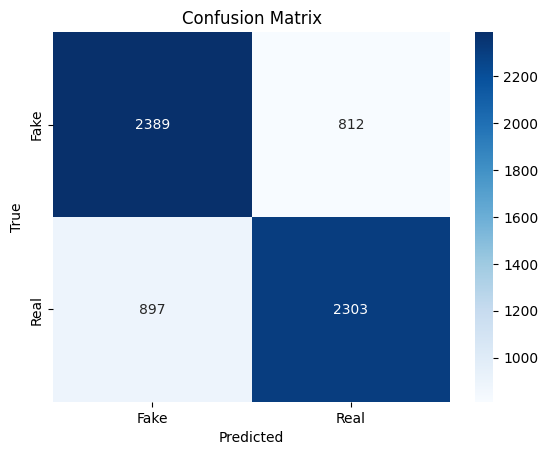

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['Review'] = augmented_reviews['Review'].apply(lambda x: synonym_replacement(x, n=2))

#기존 데이터셋과 증강된 데이터셋 결합
augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    augmented_df,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)


model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

wandb.init(project="distilbert-fake-real-review", name="distilbert-lora-training")

# TrainingArguments 설정 (하이퍼파라미터 튜닝 포함)
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 정의
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelp_output')
model.save_pretrained('/content/drive/MyDrive/results/yelp_output')

#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelp_output')
print("훈련 완료, 모델 저장 완료")

# 모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### new hyperparameter

In [14]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from peft import LoraConfig, get_peft_model
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import wandb
import random
from nltk.corpus import wordnet
import re

In [15]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 12월5일 기준 가장 잘된 모델코드 부분(에포크 수 증가)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/25603 [00:00<?, ? examples/s]

Map:   0%|          | 0/6401 [00:00<?, ? examples/s]

train/epoch,▁▂▂▃▄▄▅▅▆▇▇██
train/global_step,▁▂▂▃▄▄▅▅▆▇▇██
train/grad_norm,▁▂▁▂▂▃▄▆█▆█▇
train/learning_rate,█▇▇▆▅▅▄▄▃▂▂▁
train/loss,██▇▆▆▆▄▄▃▂▁▁
total_flos,2541983146509312.0
train/epoch,3.86473
train/global_step,2400
train/grad_norm,10.94058
train/learning_rate,0.0
train/loss,0.274


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.652300
400,0.635800
600,0.613300
800,0.602900
1000,0.590500
1200,0.571700
1400,0.569500
1600,0.553900
1800,0.465800
2000,0.442900


훈련 완료, 모델 저장 완료
Accuracy after augmentation and hyperparameter tuning: 75.08%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.74      0.77      0.76      3201
        Real       0.76      0.73      0.74      3200

    accuracy                           0.75      6401
   macro avg       0.75      0.75      0.75      6401
weighted avg       0.75      0.75      0.75      6401



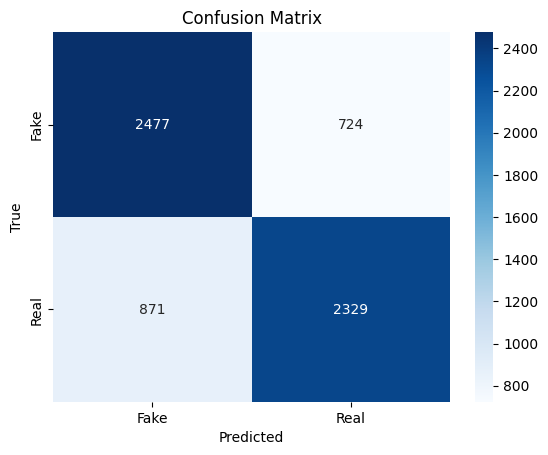

In [38]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#기존코드에서 추가한 데이터전처리 부분more
# def preprocess_text(text):
#     text = text.lower()
#     text = re.sub(r'[\^!@#?{}\[\]<>~&*()\-_+=|:;,.<>?/\\]', ' ', text)  #특수문자 및 이모티콘 제거
#     text = re.sub(r'[^\w\s]', '', text)  #구두점 제거
#     text = ' '.join([word for word in text.split() if len(word) > 1])
#     return text
# df['Review']=df['Review'].apply(preprocess_text)
#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['Review'] = augmented_reviews['Review'].apply(lambda x: synonym_replacement(x, n=2))

#기존 데이터셋과 증강된 데이터셋 결합
augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    augmented_df,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

wandb.init(project="distilbert-fake-real-review", name="distilbert-lora-training")

training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelp_output')
model.save_pretrained('/content/drive/MyDrive/results/yelp_output')

#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelp_output')
print("훈련 완료, 모델 저장 완료")

#모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#기존코드에서 추가한 데이터전처리 부분more
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[\^!@#?{}\[\]<>~&*()\-_+=|:;,.<>?/\\]', ' ', text)  #특수문자 및 이모티콘 제거
    text = re.sub(r'[^\w\s]', '', text)  #구두점 제거
    text = ' '.join([word for word in text.split() if len(word) > 1])
    return text
df['Review']=df['Review'].apply(preprocess_text)

In [ ]:
from nltk import FreqDist, bigrams
from collections import Counter
from nltk.corpus import stopwords
import nltk
from matplotlib import rc
import matplotlib.pyplot as plt


from nltk import FreqDist, bigrams
from collections import Counter

#NLTK Stopwords 다운로드
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 단어 빈도 계산 함수
def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        tokens = [word for word in text.split() if word not in stop_words]
        all_words.extend(tokens)
    freq_dist = FreqDist(all_words)
    return freq_dist.most_common(n)

#Bi-gram 빈도 계산 함수
def get_top_bigrams(texts, n=20):
    all_bigrams = []
    for text in texts:
        tokens = [word for word in text.split() if word not in stop_words]
        bigram_list = list(bigrams(tokens))
        all_bigrams.extend(bigram_list)
    bigram_freq_dist = Counter(all_bigrams)
    return bigram_freq_dist.most_common(n)

#Fake Reviews (Label 0)
fake_reviews_texts = fake_reviews['Review'].tolist()
top_fake_words = get_top_words(fake_reviews_texts)
top_fake_bigrams = get_top_bigrams(fake_reviews_texts)

#Real Reviews (Label 1)
real_reviews_texts = real_reviews['Review'].tolist()
top_real_words = get_top_words(real_reviews_texts)
top_real_bigrams = get_top_bigrams(real_reviews_texts)

#결과 출력
print("Top 20 Words in Fake Reviews:")
print(top_fake_words)

print("\nTop 20 Bigrams in Fake Reviews:")
print(top_fake_bigrams)

print("\nTop 20 Words in Real Reviews:")
print(top_real_words)

print("\nTop 20 Bigrams in Real Reviews:")
print(top_real_bigrams)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Top 20 Words in Fake Reviews:
[('food', 5968), ('place', 4350), ('good', 3872), ('great', 3835), ('service', 2745), ('like', 2247), ('go', 2135), ('one', 2042), ('restaurant', 1988), ('time', 1987), ('best', 1801), ('get', 1798), ('back', 1740), ('would', 1705), ('really', 1695), ('us', 1540), ('love', 1445), ('pizza', 1441), ('delicious', 1360), ('always', 1267)]

Top 20 Bigrams in Fake Reviews:
[(('go', 'back'), 384), (('great', 'food'), 342), (('food', 'good'), 305), (('food', 'great'), 291), (('love', 'place'), 265), (('good', 'food'), 251), (('great', 'place'), 221), (('great', 'service'), 220), (('first', 'time'), 220), (('ive', 'ever'), 216), (('really', 'good'), 215), (('highly', 'recommend'), 215), (('food', 'service'), 193), (('one', 'best'), 185), (('come', 'back'), 184), (('new', 'york'), 182), (('service', 'great'), 172), (('every', 'time'), 163), (('wait', 'staff'), 158), (('going', 'back'), 156)]

Top 20 Words in Real Reviews:
[('food', 5664), ('good', 5637), ('place', 5

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss
200,0.657500
400,0.635600
600,0.614600
800,0.601800
1000,0.589700
1200,0.575500
1400,0.568500
1600,0.556500
1800,0.470700
2000,0.450000


훈련 완료, 모델 저장 완료
Accuracy after augmentation and hyperparameter tuning: 73.83%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.73      0.75      0.74      3201
        Real       0.75      0.72      0.73      3200

    accuracy                           0.74      6401
   macro avg       0.74      0.74      0.74      6401
weighted avg       0.74      0.74      0.74      6401



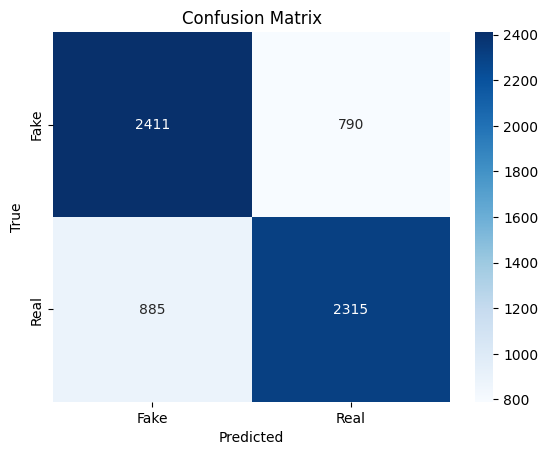

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#기존코드에서 추가한 데이터전처리 부분more
# def preprocess_text(text):
#     text = text.lower()
#     text = re.sub(r'[\^!@#?{}\[\]<>~&*()\-_+=|:;,.<>?/\\]', ' ', text)  #특수문자 및 이모티콘 제거
#     text = re.sub(r'[^\w\s]', '', text)  #구두점 제거
#     text = ' '.join([word for word in text.split() if len(word) > 1])
#     return text
# df['Review']=df['Review'].apply(preprocess_text)
#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['Review'] = augmented_reviews['Review'].apply(lambda x: synonym_replacement(x, n=2))

#기존 데이터셋과 증강된 데이터셋 결합
augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    augmented_df,
    test_size=0.2,
    random_state=42,
    stratify=augmented_df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

wandb.init(project="distilbert-fake-real-review", name="distilbert-lora-training")


training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelp_output')
model.save_pretrained('/content/drive/MyDrive/results/yelp_output')

#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelp_output')
print("훈련 완료, 모델 저장 완료")

#모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## 새로운 restaurant review(yelp가 아닌)데이터셋에 대해 테스트 해본 것

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/12086 [00:00<?, ? examples/s]

Map:   0%|          | 0/4030 [00:00<?, ? examples/s]

train/epoch,▁▂▂▃▄▄▅▅▆▇▇██
train/global_step,▁▂▂▃▄▄▅▅▆▇▇██
train/grad_norm,▁▃▂▃▂▃▅▅█▆▅▆
train/learning_rate,█▇▇▆▅▅▄▄▃▂▂▁
train/loss,█▇▇▆▆▆▅▅▂▂▁▂
total_flos,2542513016103936.0
train/epoch,1.49906
train/global_step,2400
train/grad_norm,6.33505
train/learning_rate,0.0
train/loss,0.4666


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.067100
400,0.011400
600,0.016100
800,0.009000
1000,0.000800
1200,0.002900
1400,0.003300
1600,0.005700
1800,0.000100
2000,0.000100


훈련 완료, 모델 저장 완료
Accuracy: 99.85%
Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1986
        Real       1.00      1.00      1.00      2044

    accuracy                           1.00      4030
   macro avg       1.00      1.00      1.00      4030
weighted avg       1.00      1.00      1.00      4030



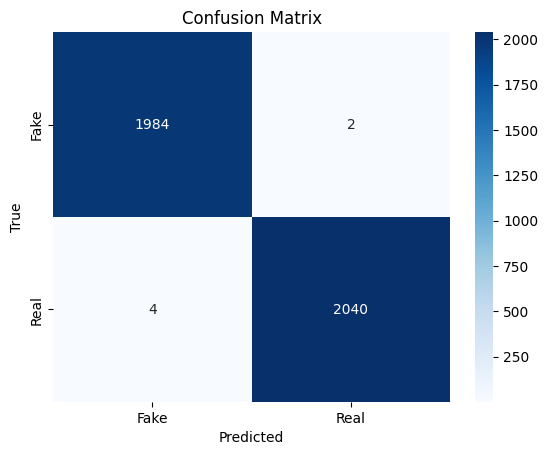

In [ ]:
#데이터 로드
train_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/train.csv"
test_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()
#모델 및 토크나이저 초기화
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

#WandB 설정
wandb.init(project="distilbert-fake-real-review", name="distilbert-restaurant-review")

#학습 설정
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/restaurant_output')
model.save_pretrained('/content/drive/MyDrive/results/restaurant_output')
tokenizer.save_pretrained('/content/drive/MyDrive/results/restaurant_output')
print("훈련 완료, 모델 저장 완료")

#모델 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#저장된 모델 경로
model_path = '/content/drive/MyDrive/results/yelp_output'

#모델 및 토크나이저 로드
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path)
model.eval()

#테스트 데이터 로드
test_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/test.csv"
test_df = pd.read_csv(test_path)
#테스트 데이터 레이블 반전 (0 -> 1, 1 -> 0)
test_df['label'] = test_df['label'].apply(lambda x: 1 if x == 0 else 0)
test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

#토크나이저 함수
def tokenize_function(texts):
    return tokenizer(texts, padding='max_length', truncation=True, max_length=256, return_tensors="pt")

#테스트 데이터 토큰화
tokenized_test = tokenize_function(test_texts)

#모델 평가
predicted_labels = []
true_labels = test_labels

with torch.no_grad():
    input_ids = tokenized_test['input_ids']
    attention_mask = tokenized_test['attention_mask']

    batch_size = 16
    for i in range(0, len(input_ids), batch_size):
        batch_input_ids = input_ids[i:i+batch_size]
        batch_attention_mask = attention_mask[i:i+batch_size]

        outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        predicted_labels.extend(predictions)

# 성능 평가
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

# Confusion Matrix
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


KeyboardInterrupt: 

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss
200,0.085500
400,0.019200
600,0.007300
800,0.012400
1000,0.007000
1200,0.003500
1400,0.002300
1600,0.002600
1800,0.000100
2000,0.000100


훈련 완료, 모델 저장 완료
Accuracy: 99.95%
Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      1986
        Real       1.00      1.00      1.00      2044

    accuracy                           1.00      4030
   macro avg       1.00      1.00      1.00      4030
weighted avg       1.00      1.00      1.00      4030



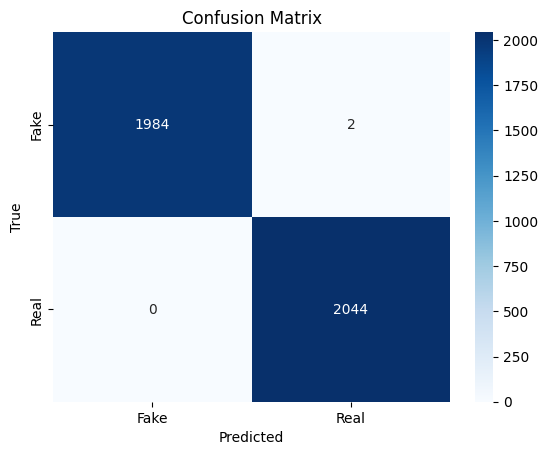

In [ ]:
import pandas as pd
import random
from nltk.corpus import wordnet
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import Trainer, TrainingArguments

# NLTK 다운로드
import nltk
nltk.download('wordnet')

# 데이터 로드
train_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/train.csv"
test_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

#데이터 증강 함수 정의 (Synonym Replacement)
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))  # 중복된 단어를 없애기 위해 set으로 변경
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()  # 첫 번째 동의어 선택
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = train_df.copy()
augmented_reviews['text'] = augmented_reviews['text'].apply(lambda x: synonym_replacement(x, n=2))

train_texts_augmented = augmented_reviews['text'].tolist()
train_labels_augmented = augmented_reviews['label'].tolist()


model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts_augmented, 'label': train_labels_augmented}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

import wandb
wandb.init(project="distilbert-fake-real-review", name="distilbert-restaurant-review")

#학습 설정
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2000,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 생성
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/restaurant_new_output')
model.save_pretrained('/content/drive/MyDrive/results/restaurant_new_output')
tokenizer.save_pretrained('/content/drive/MyDrive/results/restaurant_new_output')
print("훈련 완료, 모델 저장 완료")

#모델 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


Accuracy: 49.81%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.50      1.00      0.66      1591
        Real       0.64      0.00      0.01      1609

    accuracy                           0.50      3200
   macro avg       0.57      0.50      0.34      3200
weighted avg       0.57      0.50      0.33      3200



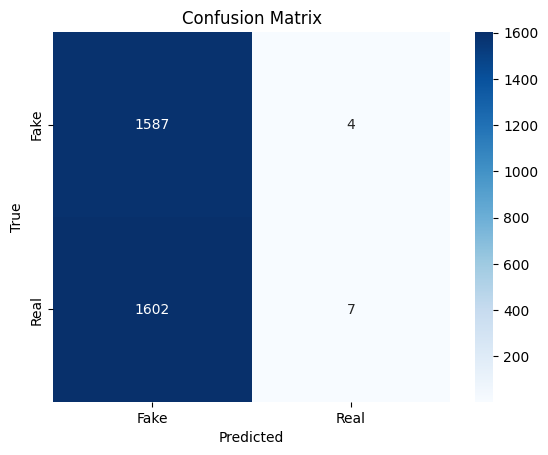

In [ ]:
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt

#저장된 모델 및 토크나이저 로드
model_path = '/content/drive/MyDrive/results/restaurant_new_output'
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizer.from_pretrained(model_path)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

data_path = "/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv"
data_df = pd.read_csv(data_path)

sampled_df = data_df.sample(frac=0.2, random_state=42)

sampled_df['Label'] = sampled_df['Label'].apply(lambda x: 1 if x == 0 else 0)

texts = sampled_df['Review'].tolist()
labels = sampled_df['Label'].tolist()

batch_size = 16
inputs = []
for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i + batch_size]
    inputs_batch = tokenizer(batch_texts, padding='max_length', truncation=True, max_length=256, return_tensors='pt')
    inputs.append(inputs_batch)

#텐서 합치기
inputs = {key: torch.cat([batch[key] for batch in inputs], dim=0) for key in inputs[0].keys()}


inputs = {key: value.to(device) for key, value in inputs.items()}
true_labels = torch.tensor(labels).to(device)

#모델 예측 수행
model.eval()
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_labels = torch.argmax(logits, axis=1)

#결과 평가
predicted_labels = predicted_labels.cpu().numpy()
true_labels = true_labels.cpu().numpy()

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

#Confusion Matrix 시각화
cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


[nltk_data] Downloading package wordnet to /root/nltk_data...


Map:   0%|          | 0/8060 [00:00<?, ? examples/s]

Accuracy after augmentation and hyperparameter tuning: 55.91%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.65      0.29      0.40      4088
        Real       0.53      0.84      0.65      3972

    accuracy                           0.56      8060
   macro avg       0.59      0.56      0.53      8060
weighted avg       0.59      0.56      0.52      8060



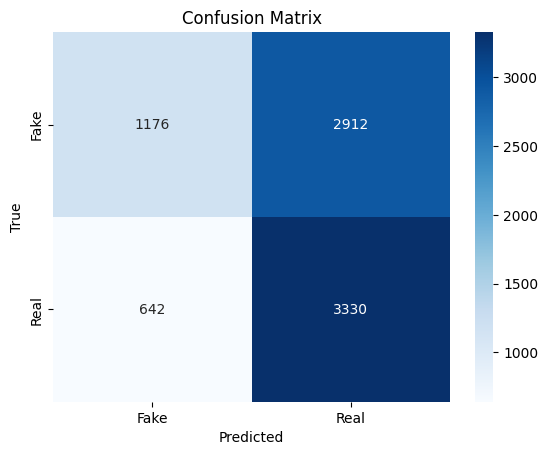

In [ ]:
import pandas as pd
import random
from nltk.corpus import wordnet
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import Trainer, TrainingArguments

#NLTK 다운로드
import nltk
nltk.download('wordnet')

#데이터 로드
test_path = "/content/drive/MyDrive/2. 형태소 분석/dataset/restaurantreview/test.csv"
df = pd.read_csv(test_path)

#데이터 증강 함수 정의
def synonym_replacement(text, n=1):
    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()  # 첫 번째 동의어 선택
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
augmented_reviews = df.copy()
augmented_reviews['text'] = augmented_reviews['text'].apply(lambda x: synonym_replacement(x, n=2))

augmented_df = pd.concat([df, augmented_reviews]).reset_index(drop=True)

#모델 로드 및 데이터 준비
model_path = '/content/drive/MyDrive/results/yelp_output'  # 미리 학습된 모델 경로
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
model = DistilBertForSequenceClassification.from_pretrained(model_path, num_labels=2)

#토큰화 함수
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

#데이터 준비
test_texts = augmented_df['text'].tolist()
test_labels = augmented_df['label'].tolist()

#`test.csv` 라벨 변환 (진짜는 0, 가짜는 1로 변환)
test_labels = [1 if label == 0 else 0 for label in test_labels]  # 0 -> 1, 1 -> 0

#Dataset 객체로 변환
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

#모델 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after augmentation and hyperparameter tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## new version

In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from peft import LoraConfig, get_peft_model
import re
import wandb
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import random
from nltk.corpus import wordnet
from nltk.tokenize import RegexpTokenizer
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
!pip install sentence-transformers

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

#데이터 라벨별 샘플 개수 확인
fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 전처리 함수: 불용어 제거 및 어간 추출
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    tokenizer = RegexpTokenizer(r'\w+')
    words = tokenizer.tokenize(text.lower())  # 소문자화 및 토큰화
    words = [word for word in words if word not in stop_words]  # 불용어 제거
    ps = PorterStemmer()
    words = [ps.stem(word) for word in words]  # 어간 추출
    return ' '.join(words)

#전처리 적용
df['Review'] = df['Review'].apply(preprocess_text)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()

#DistilBERT 모델과 토크나이저 설정
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

#DistilBERT 모델 로드
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = Dataset.from_dict({'text': train_texts, 'label': train_labels}).map(tokenize_function, batched=True)
test_dataset = Dataset.from_dict({'text': test_texts, 'label': test_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset = test_dataset.with_format("torch", columns=["input_ids", "attention_mask", "label"])

#wandb 설정
wandb.init(project="distilbert-fake-real-review", name="distilbert-tuning")

#TrainingArguments 설정
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",  # 평가를 하지 않도록 설정
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb",
    lr_scheduler_type="linear",  # 학습률 선형 스케줄러 사용
)

#Trainer 정의 (eval_dataset=None으로 설정)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None  # 평가 데이터셋을 None으로 설정
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/new_output')
model.save_pretrained('/content/drive/MyDrive/results/new_output')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/12801 [00:00<?, ? examples/s]

Map:   0%|          | 0/3201 [00:00<?, ? examples/s]

train/epoch,▁
train/global_step,▁
train/grad_norm,▁
train/learning_rate,▁
train/loss,▁
train/epoch,0.24969
train/global_step,200
train/grad_norm,4.68133
train/learning_rate,2e-05
train/loss,0.6696


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs


Step,Training Loss
200,0.663800
400,0.650900
600,0.633000
800,0.640200
1000,0.606800
1200,0.597500
1400,0.588800
1600,0.586500
1800,0.530700
2000,0.543100


훈련 완료, 모델 저장 완료
Accuracy after data preprocessing and tuning: 67.04%
Classification Report:
              precision    recall  f1-score   support

        Fake       0.66      0.70      0.68      1601
        Real       0.68      0.64      0.66      1600

    accuracy                           0.67      3201
   macro avg       0.67      0.67      0.67      3201
weighted avg       0.67      0.67      0.67      3201



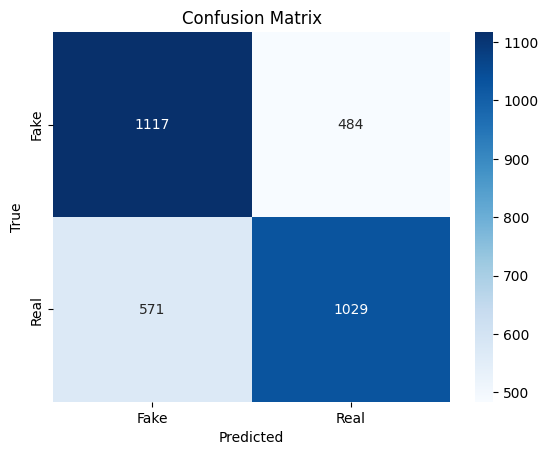

In [ ]:
#토크나이저 저장
tokenizer.save_pretrained('/content/drive/MyDrive/results/new_output')
print("훈련 완료, 모델 저장 완료")

#모델 성능 평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        labels = batch['label'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy after data preprocessing and tuning: {accuracy * 100:.2f}%")

print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### 머신러닝기법으로만...?

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.utils import shuffle

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Accuracy: 64.17%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.63      0.68      0.65      1601
        Real       0.65      0.61      0.63      1600

    accuracy                           0.64      3201
   macro avg       0.64      0.64      0.64      3201
weighted avg       0.64      0.64      0.64      3201



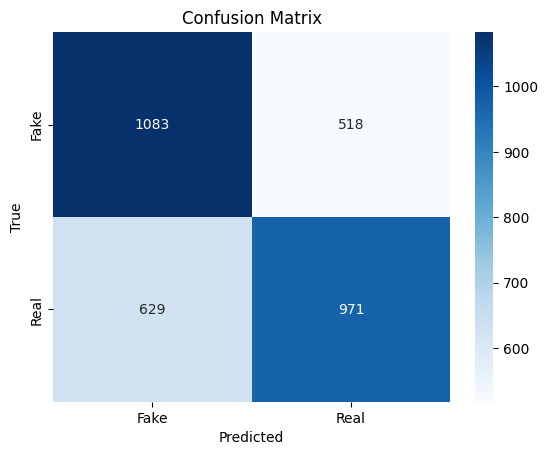

In [ ]:
# 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")

fake_reviews = df[df['Label'] == 0]
real_reviews = df[df['Label'] == 1]
assert len(fake_reviews) == 8001, "가짜 리뷰 샘플 개수 확인 필요"
assert len(real_reviews) == 8001, "진짜 리뷰 샘플 개수 확인 필요"

#데이터 증강 (옵션)
def synonym_replacement(text, n=1):
    from nltk.corpus import wordnet
    import random

    words = text.split()
    new_words = words.copy()
    random_word_list = list(set(words))
    random.shuffle(random_word_list)
    num_replaced = 0

    for random_word in random_word_list:
        synonyms = wordnet.synsets(random_word)
        if len(synonyms) > 0:
            synonym = synonyms[0].lemmas()[0].name()
            new_words = [synonym if word == random_word else word for word in new_words]
            num_replaced += 1
        if num_replaced >= n:
            break

    return ' '.join(new_words)

#데이터 증강 적용
df['Reviewed'] = df['Review'].apply(lambda x: synonym_replacement(x, n=2))

#데이터 셔플 및 Train/Test 분리
df = shuffle(df, random_state=42).reset_index(drop=True)
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

train_texts = train_data['Reviewed'].tolist()
train_labels = train_data['Label'].tolist()
test_texts = test_data['Reviewed'].tolist()
test_labels = test_data['Label'].tolist()

#TF-IDF 벡터화
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),  #unigram과 bigram 활용
    stop_words=stopwords.words('english')  #불용어 제거
)

X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

#Random Forest 모델 학습
model = RandomForestClassifier(
    n_estimators=200,  #트리 수
    max_depth=20,  #트리 최대 깊이
    random_state=42,
    n_jobs=-1  #병렬 처리
)
model.fit(X_train, train_labels)

#예측 및 평가
predicted_labels = model.predict(X_test)
accuracy = accuracy_score(test_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(test_labels, predicted_labels, target_names=["Fake", "Real"]))

#Confusion Matrix 시각화
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import pandas as pd
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from gensim.models import LdaModel
from gensim.corpora.dictionary import Dictionary
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import wandb

In [ ]:
# NLTK 다운로드
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# 데이터 로드
df = pd.read_csv("/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv")
#데이터 전처리
stop_words = set(stopwords.words('english'))
def preprocess(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalnum() and word not in stop_words]
df['tokens'] = df['Review'].apply(preprocess)
#LDA 모델 학습
dictionary = Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, random_state=42)

#각 텍스트의 토픽 분포 추출
def get_topic_distribution(text):
    bow = dictionary.doc2bow(preprocess(text))
    topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0)
    return [prob for _, prob in sorted(topic_distribution)]

df['topic_distribution'] = df['Review'].apply(get_topic_distribution)

#Train/Test 데이터 분리
train_data, test_data = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['Label']
)

train_texts = train_data['Review'].tolist()
train_labels = train_data['Label'].tolist()
train_topics = np.array(train_data['topic_distribution'].tolist())

test_texts = test_data['Review'].tolist()
test_labels = test_data['Label'].tolist()
test_topics = np.array(test_data['topic_distribution'].tolist())

#DistilBERT 모델 및 토크나이저 설정
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

#데이터 토큰화 및 토픽 분포 추가
def tokenize_function(examples, topics):
    tokens = tokenizer(examples, padding='max_length', truncation=True, max_length=256, return_tensors="pt")
    tokens['topics'] = torch.tensor(topics, dtype=torch.float32)
    return tokens

train_encodings = tokenize_function(train_texts, train_topics)
test_encodings = tokenize_function(test_texts, test_topics)

#학습 데이터 준비
class YelpDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = YelpDataset(train_encodings, train_labels)
test_dataset = YelpDataset(test_encodings, test_labels)

wandb.init(project="distilbert-lda", name="distilbert-with-lda")

#학습 파라미터 설정
training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/results',
    evaluation_strategy="no",
    eval_steps=200,
    logging_dir='/content/drive/MyDrive/results/logs',
    logging_steps=200,
    save_steps=200,
    max_steps=2400,
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="steps",
    fp16=True,
    report_to="wandb"
)

#Trainer 설정
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=None
)

#모델 학습
trainer.train()
trainer.save_model('/content/drive/MyDrive/results/yelps_output')
model.save_pretrained('/content/drive/MyDrive/results/yelps_output')
tokenizer.save_pretrained('/content/drive/MyDrive/results/yelps_output')
print("모델 학습 및 저장 완료!")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
max_steps is given, it will override any value given in num_train_epochs
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Step,Training Loss
200,0.665400
400,0.633800
600,0.627300
800,0.623300
1000,0.573700
1200,0.539200
1400,0.554000
1600,0.537500
1800,0.450500
2000,0.433200


모델 학습 및 저장 완료!


Accuracy: 67.42%
              precision    recall  f1-score   support

        Fake       0.67      0.68      0.68      1601
        Real       0.68      0.66      0.67      1600

    accuracy                           0.67      3201
   macro avg       0.67      0.67      0.67      3201
weighted avg       0.67      0.67      0.67      3201



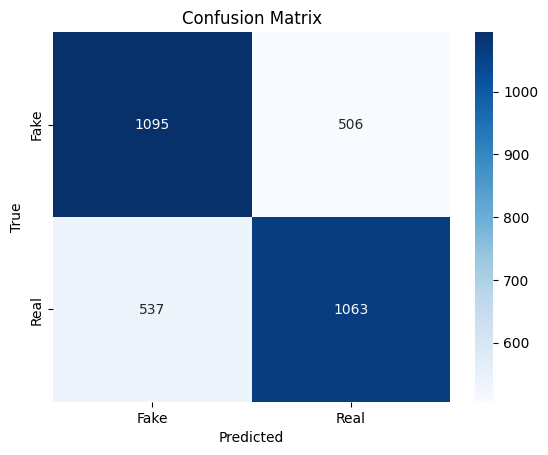

In [ ]:
#평가
predicted_labels = []
true_labels = []

with torch.no_grad():
    for batch in torch.utils.data.DataLoader(test_dataset, batch_size=16):
        input_ids = batch['input_ids'].to(model.device)
        attention_mask = batch['attention_mask'].to(model.device)
        topics = batch['topics'].to(model.device)
        labels = batch['labels'].to(model.device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        predicted_labels.extend(torch.argmax(logits, dim=1).cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(true_labels, predicted_labels, target_names=["Fake", "Real"]))

cm = confusion_matrix(true_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#dataset= pd.read_csv('metadata.csv')
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.corpus import stopwords
stopword_list=nltk.corpus.stopwords.words('english')
stopword_list.remove('no')
stopword_list.remove('not')
from nltk.stem.porter import PorterStemmer
import random

dataset= pd.read_csv('/content/drive/MyDrive/2. 형태소 분석/yelpreview.csv')
#DATA PREPROCESSING
X=dataset.iloc[0:16002,[0,1,5,6,2]].values
corpus=[]
for i in range(0,16002):
        review=re.sub('[^a-zA-Z]', ' ',str(dataset['Review'][i]))
        review=review.lower()
        review=review.split()
        ps=PorterStemmer()
        review = [ps.stem(word) for word in review if not word in set(stopword_list)]
        review=' '.join(review)
        corpus.append(review)

#POS TAGGING
from nltk.tokenize import word_tokenize, sent_tokenize
text=[]
for i in range(0,16002):
    texte = word_tokenize(dataset['Review'][i])
    text.append(texte)
    text[i]=nltk.pos_tag(text[i])

count=[]
for i in range(0,16002):
    words, tags=zip(*text[i])
    count.append(tags)
    count[i]=' '.join(count[i])

from sklearn.feature_extraction.text import CountVectorizer
tup=CountVectorizer()
X2=tup.fit_transform(count).toarray()
tup.get_feature_names_out()

#BIGRAMS
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(ngram_range=(2,2),max_features=100)
X7 = count_vect.fit_transform(corpus).toarray()
count_vect.get_feature_names_out()

#UNIGRAMS
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100)
X1=cv.fit_transform(corpus).toarray()
cv.get_feature_names_out()

#DEPENDENT VARIABLE
y1=dataset.iloc[0:16002,3].values



# positive negative
l7=[]
for i in range(0,16002):
    if(int(X[i][4])>3):
        l7.append([1])
    else:
        l7.append([0])


#CREATING INDEPENDENT VARIABLES
X1=pd.DataFrame(X1)
X7=pd.DataFrame(X7)
X2=pd.DataFrame(X2)
l1=[]
l2=[]
l3=[]
l4=[]
l5=[]
l6=[]
for i in range(0,16002):
        d,m,y=X[i][3].split("-")
        l1.append([d])
        l2.append([m])
        l3.append([y])
        l4.append([X[i][0]])
        l5.append([X[i][1]])
        l6.append([X[i][2]])
X = pd.DataFrame(X)
dff4=np.concatenate([l1,l2,l3,l4,l5,l6,l7],axis=1)
dff4=pd.DataFrame(dff4)
dff4=np.concatenate([dff4,X1,X7,X2],axis=1)


#FINAL SET OF INDEPENDENT VARIABLES






#Logistic Regression
from sklearn.model_selection import train_test_split
dff4=pd.DataFrame(dff4)
y=pd.Series(y1)
X_train_L, X_test_L, y_train_L, y_test_L = train_test_split(dff4, y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_L = sc.fit_transform(X_train_L)
X_test_L = sc.transform(X_test_L)

'''
#applying lda
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda=LDA(n_components=50)
X_train_L=lda.fit_transform(X_train_L,y_train_L)
X_test_L=lda.transform(X_test_L)
'''
# Fitting Logistic Regression to the Training set
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train_L, y_train_L)

# Predicting the Test set results
y_pred_L = classifier.predict(X_test_L)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_L, y_pred_L)

from sklearn.metrics import accuracy_score
accuracy_L = accuracy_score(y_test_L,y_pred_L)
print(accuracy_L)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


0.683329167708073


In [13]:
#naive_bayes
X_train, X_test, y_train, y_test = train_test_split(dff4, y1, test_size = 0.25, random_state = 0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test= sc.transform(X_test)

'''#applying lda
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda=LDA(n_components=150)
X_train=lda.fit_transform(X_train,y_train)
X_test=lda.transform(X_test)
'''


from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)



from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("asd",accuracy)

asd 0.5866033491627093
